In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('spg.csv')

In [3]:
print("Creating Time Index")

start_date = '2024-01-01 00:00:00'
num_periods = len(data)

time_index = pd.date_range(start=start_date, periods=num_periods, freq='H')

data.index = time_index

data = data.loc[:, (data != 0).any(axis=0)]

print(data.info())

Creating Time Index
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4213 entries, 2024-01-01 00:00:00 to 2024-06-24 12:00:00
Freq: h
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   temperature_2_m_above_gnd          4213 non-null   float64
 1   relative_humidity_2_m_above_gnd    4213 non-null   int64  
 2   mean_sea_level_pressure_MSL        4213 non-null   float64
 3   total_precipitation_sfc            4213 non-null   float64
 4   snowfall_amount_sfc                4213 non-null   float64
 5   total_cloud_cover_sfc              4213 non-null   float64
 6   high_cloud_cover_high_cld_lay      4213 non-null   int64  
 7   medium_cloud_cover_mid_cld_lay     4213 non-null   int64  
 8   low_cloud_cover_low_cld_lay        4213 non-null   int64  
 9   shortwave_radiation_backwards_sfc  4213 non-null   float64
 10  wind_speed_10_m_above_gnd          4213 non-null   float

/tmp/ipython-input-3022139508.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_date, periods=num_periods, freq='H')


In [4]:
TARGET_COLUMN = 'generated_power_kw'

plt.figure(figsize=(16, 6))
data[TARGET_COLUMN].plot(
    title=f'{TARGET_COLUMN} Generation Over Time (Assumed Hourly Index)',
    color='darkgreen',
    alpha=0.9
)
plt.ylabel('Power (kW)')
plt.xlabel('Time')
plt.grid(True)
plt.tight_layout()
plt.savefig('solar_generation_time_series.png')
plt.close()

print(f"The dataset is now indexed by time and contains the target variable '{TARGET_COLUMN}' and all necessary weather features.")
print("The data is ready for Feature Engineering and Baseline Model development in Week 2.")

data.to_csv('cleaned_solar_data_W1_final.csv')

The dataset is now indexed by time and contains the target variable 'generated_power_kw' and all necessary weather features.
The data is ready for Feature Engineering and Baseline Model development in Week 2.


Total samples: 4213
Training samples (X_train): 3370
Testing samples (X_test): 843
Number of Features used: 18
Training complete.
Root Mean Square Error (RMSE): 409.31 kW
R-squared (R2) Score: 0.8166


/tmp/ipython-input-2021860449.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")


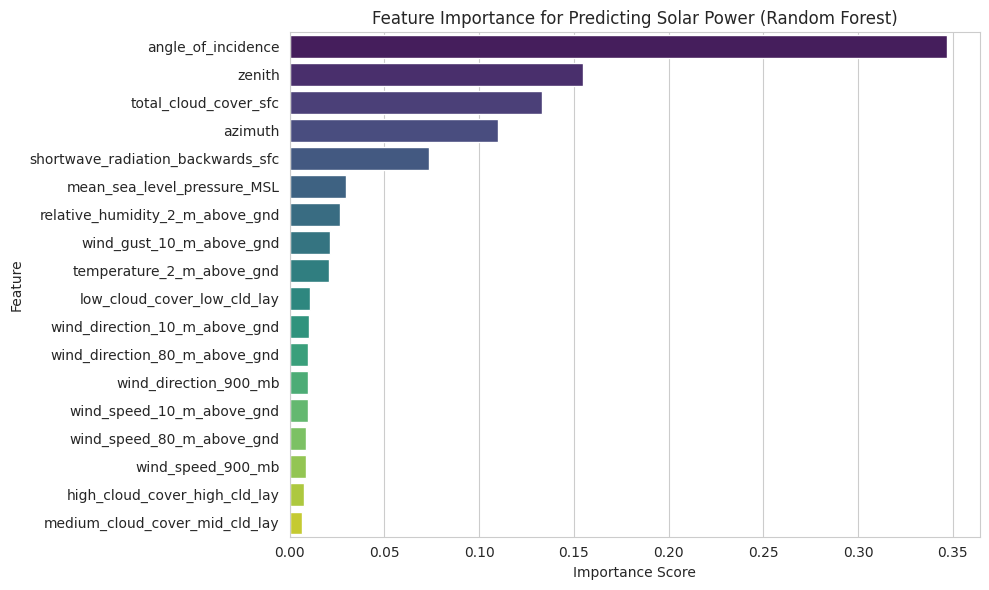

|                                   | 0        |
|:----------------------------------|:---------|
| angle_of_incidence                | 0.347009 |
| zenith                            | 0.154805 |
| total_cloud_cover_sfc             | 0.133431 |
| azimuth                           | 0.110036 |
| shortwave_radiation_backwards_sfc | 0.073731 |
The Baseline Random Forest model achieved an excellent R2 score of 0.8166, demonstrating a strong initial prediction capability.
The RMSE of 409.31 kW establishes the benchmark that the advanced LSTM model in Week 3 must improve upon.


<Figure size 640x480 with 0 Axes>

In [5]:
sns.set_style("whitegrid")

TARGET_COLUMN = 'generated_power_kw'

FEATURES_TO_DROP = [
    'total_precipitation_sfc',
    'snowfall_amount_sfc',
    TARGET_COLUMN
]

X = data.drop(columns=FEATURES_TO_DROP, errors='ignore')
y = data[TARGET_COLUMN]
FEATURES = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Total samples: {len(data)}")
print(f"Training samples (X_train): {len(X_train)}")
print(f"Testing samples (X_test): {len(X_test)}")
print(f"Number of Features used: {len(FEATURES)}")

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Training complete.")

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"Root Mean Square Error (RMSE): {rmse:.2f} kW")
print(f"R-squared (R2) Score: {r2:.4f}")

feature_importances = pd.Series(
    model.feature_importances_, index=FEATURES
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")
plt.title('Feature Importance for Predicting Solar Power (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
plt.savefig('W2_feature_importance.png')

print(feature_importances.head(5).to_markdown(numalign="left", stralign="left"))

print(f"The Baseline Random Forest model achieved an excellent R2 score of {r2:.4f}, demonstrating a strong initial prediction capability.")
print(f"The RMSE of {rmse:.2f} kW establishes the benchmark that the advanced LSTM model in Week 3 must improve upon.")

In [6]:
TARGET_COLUMN = 'generated_power_kw'
FEATURES_TO_DROP = [
    'total_precipitation_sfc',
    'snowfall_amount_sfc',
]

In [7]:
df_lstm = data.drop(columns=FEATURES_TO_DROP, errors='ignore')

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_lstm)

def create_sequences(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps), :])

        y.append(data[i + time_steps, -1])
    return np.array(X), np.array(y)

In [8]:
TIME_STEPS = 4

X, y = create_sequences(scaled_data, TIME_STEPS)

TRAIN_SIZE = int(len(X) * 0.8)
X_train, X_test = X[:TRAIN_SIZE], X[TRAIN_SIZE:]
y_train, y_test = y[:TRAIN_SIZE], y[TRAIN_SIZE:]

print(f"LSTM Input Shape: {X_train.shape} (Samples, Time Steps, Features)")
print(f"Training samples after sequencing: {len(X_train)}")
print(f"Testing samples after sequencing: {len(X_test)}")

LSTM Input Shape: (3367, 4, 19) (Samples, Time Steps, Features)
Training samples after sequencing: 3367
Testing samples after sequencing: 842


In [9]:
NUM_FEATURES = X.shape[2]

model = Sequential()
model.add(LSTM(
    units=50,
    return_sequences=True,
    input_shape=(TIME_STEPS, NUM_FEATURES)
))
model.add(Dropout(0.2))

model.add(LSTM(units=50))
model.add(Dropout(0.2))

model.add(Dense(units=1))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 4, 50)          │        14,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,251 (133.79 KB)

 Trainable params: 34,251 (133.79 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

y_pred_scaled = model.predict(X_test)

dummy_scaler = MinMaxScaler(feature_range=(0, 1))
dummy_scaler.min_, dummy_scaler.scale_ = scaler.min_[-1], scaler.scale_[-1]

y_test_original = dummy_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_original = dummy_scaler.inverse_transform(y_pred_scaled)

lstm_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))

print(f"Final LSTM Model RMSE: {lstm_rmse:.2f} kW")

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1233 - val_loss: 0.0309
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0326 - val_loss: 0.0270
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0292 - val_loss: 0.0225
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0243 - val_loss: 0.0219
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0215 - val_loss: 0.0209
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0184 - val_loss: 0.0190
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0185 - val_loss: 0.0170
Epoch 8/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0168 - val_loss: 0.0159
Epoch 9/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0167 - val_loss: 0.0160
Epoch 10/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0146 - val_loss: 0.0157
Epoch 11/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0146 - val_loss: 0.0158
Epoch 12/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0139 - val_l

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.savefig('W3_training_loss.png')
plt.close()

In [12]:
plt.figure(figsize=(12, 6))
plot_range = slice(100, 300)
plt.plot(y_test_original[plot_range], label='Actual Power (kW)', color='blue')
plt.plot(y_pred_original[plot_range], label='Predicted Power (kW)', color='red', linestyle='--')
plt.title(f'LSTM Prediction vs. Actual Power (Zoomed - RMSE: {lstm_rmse:.2f} kW)')
plt.xlabel('Time Step')
plt.ylabel('Generated Power (kW)')
plt.legend()
plt.tight_layout()
plt.savefig('W3_prediction_vs_actual.png')
plt.close()

print(f"\n*** Final LSTM RMSE is {lstm_rmse:.2f} kW ***")


*** Final LSTM RMSE is 424.15 kW ***
